Matches found: ['image_04001_eth_0.png', 'image_04001_html_0.png', 'image_04001_url_0.png']
Selected stego image: ../stegoimagesdataset/test/test/stego\image_04001_eth_0.png
Processing: ../stegoimagesdataset/test/test/clean\04001.png with noise: none


C:\Users\kilio\AppData\Local\Temp\ipykernel_11748\2827100733.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


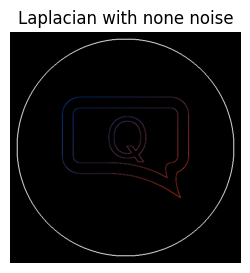

Prédiction : Clean (Probas: Clean=1.000, Stego=0.000)
Processing: ../stegoimagesdataset/test/test/stego\image_04001_eth_0.png with noise: none


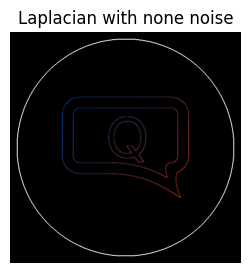

Prédiction : Stego (Probas: Clean=0.067, Stego=0.933)

Cosine similarity between clean and stego feature vectors: 0.720476

Clean feature vector snippet: [0.01957719 0.4925539  0.05288769 1.3047292  0.05328074 1.0404284
 0.01212165 0.69165355 1.1352086  0.16579738]
Stego feature vector snippet: [0.5796988  0.36798492 0.6219888  0.82987165 0.04863755 0.76560175
 0.6089531  0.6777773  0.5274441  0.79879975]


In [38]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import re
import os
import random
from scipy.spatial.distance import cosine


def add_gaussian_noise(img_np, mean=0, std=10):
    noise = np.random.normal(mean, std, img_np.shape).astype(np.float32)
    noisy = img_np.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(img_np, amount=0.01):
    output = img_np.copy()
    num_salt = int(np.ceil(amount * img_np.size * 0.5))
    coords = [np.random.randint(0, i - 1, num_salt) for i in img_np.shape[:2]]
    output[coords[0], coords[1]] = 255

    num_pepper = int(np.ceil(amount * img_np.size * 0.5))
    coords = [np.random.randint(0, i - 1, num_pepper) for i in img_np.shape[:2]]
    output[coords[0], coords[1]] = 0
    return output

def add_blur(img_np, kernel_size=3):
    return cv2.blur(img_np, (kernel_size, kernel_size))

def apply_laplacian_rgb(img_pil, noise="none"):
    img_np = np.array(img_pil)

    if noise == "gaussian":
        img_np = add_gaussian_noise(img_np)
    elif noise == "salt_pepper":
        img_np = add_salt_pepper_noise(img_np)
    elif noise == "blur":
        img_np = add_blur(img_np)

    laplacian_channels = []
    for c in range(3):
        channel = img_np[:, :, c]
        lap = cv2.Laplacian(channel, cv2.CV_32F)
        lap = cv2.convertScaleAbs(lap)
        laplacian_channels.append(lap)

    img_lap = np.stack(laplacian_channels, axis=-1)
    return Image.fromarray(img_lap)

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

model = models.resnet18(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 2)
)


model_path = "../Models/Thebestsofar/with_Laplacian/with_laplacian_with_noise.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.load_state_dict(torch.load(model_path))
model = model.to(device).eval()

clean_img = "04001.png"
clean_dir = "../stegoimagesdataset/test/test/clean"
stego_dir = "../stegoimagesdataset/test/test/stego"

clean_path = os.path.join(clean_dir, clean_img)
base_id = os.path.splitext(clean_img)[0]
pattern = f"image_{base_id}_.+\\.png"
stego_matches = [f for f in os.listdir(stego_dir) if re.match(pattern, f)]
if stego_matches:
    print(f"Matches found: {stego_matches}")
    stego_img = random.choice(stego_matches)
    stego_path = os.path.join(stego_dir, stego_img)

if stego_path:
    print(f"Selected stego image: {stego_path}")
    images = [clean_path, stego_path]
else:
    print("No matching stego image found.")
    images = [clean_path]

noise_type = "none"  # "none", "gaussian", "salt_pepper", "blur"

feature_store = {}

def hook_fn(module, input, output):
    feature_store['features'] = output.view(output.size(0), -1)  # flatten (B, 512)

# Register on the last layer before classification
model.avgpool.register_forward_hook(hook_fn)

features_list = []

for image_path in images:
    print(f"Processing: {image_path} with noise: {noise_type}")
    img = Image.open(image_path).convert("RGB")
    img_lap = apply_laplacian_rgb(img, noise=noise_type)

    plt.figure(figsize=(3, 3))
    plt.imshow(img_lap)
    plt.title(f"Laplacian with {noise_type} noise")
    plt.axis('off')
    plt.show()

    input_tensor = transform(img_lap).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.softmax(output, dim=1)
        pred = torch.argmax(prob, dim=1).item()

    print(f"Prédiction : {'Stego' if pred == 1 else 'Clean'} (Probas: Clean={prob[0,0]:.3f}, Stego={prob[0,1]:.3f})")

    features_list.append(feature_store['features'].cpu().numpy().flatten())

if len(features_list) == 2:
    clean_feat, stego_feat = features_list
    similarity = 1 - cosine(clean_feat, stego_feat)
    print(f"\nCosine similarity between clean and stego feature vectors: {similarity:.6f}")
    print("\nClean feature vector snippet:", clean_feat[:10])
    print("Stego feature vector snippet:", stego_feat[:10])
else:
    print("Only one image processed; cannot compare features.")


C:\Users\kilio\AppData\Local\Temp\ipykernel_15724\1936032751.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00         0
       Stego       1.00      0.94      0.97      1000

    accuracy                           0.94      1000
   macro avg       0.50      0.47      0.48      1000
weighted avg       1.00      0.94      0.97      1000



d:\anaconda3\envs\torch_cuda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\anaconda3\envs\torch_cuda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\anaconda3\envs\torch_cuda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


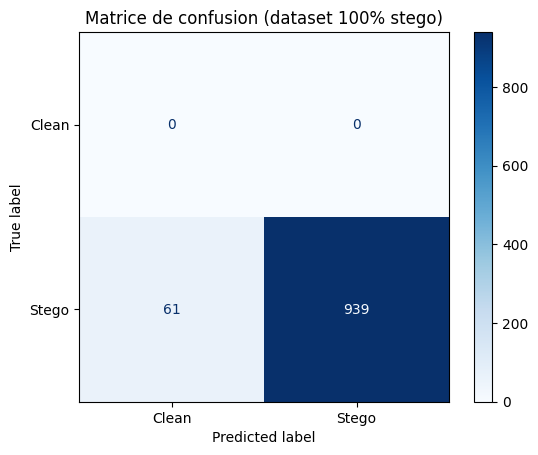

In [2]:
import os
import random
import torch
import torch.nn as nn
import numpy as np
from torchvision import transforms, models
from PIL import Image
import cv2
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

stego_dir = "other_dataset"
num_samples = 1000

model = models.resnet18(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 2)
)
model_path = "Models/Thebestsofar/best_model.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(model_path))
model = model.to(device).eval()

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def apply_laplacian_rgb(img_pil, noise="none"):
    img_np = np.array(img_pil)

    if noise == "gaussian":
        img_np = add_gaussian_noise(img_np)
    elif noise == "salt_pepper":
        img_np = add_salt_pepper_noise(img_np)
    elif noise == "blur":
        img_np = add_blur(img_np)

    laplacian_channels = []
    for c in range(3):
        channel = img_np[:, :, c]
        lap = cv2.Laplacian(channel, cv2.CV_32F)
        lap = cv2.convertScaleAbs(lap)
        laplacian_channels.append(lap)

    img_lap = np.stack(laplacian_channels, axis=-1)
    return Image.fromarray(img_lap)



image_files = [f for f in os.listdir(stego_dir) if f.endswith('.png')]
image_files = random.sample(image_files, min(len(image_files), num_samples))

y_true, y_pred = [], []

with torch.no_grad():
    for file in image_files:
        img = Image.open(os.path.join(stego_dir, file)).convert("RGB")
        img_lap = apply_laplacian_rgb(img, noise="none")
        input_tensor = transform(img_lap).unsqueeze(0).to(device)
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        
        y_true.append(1)
        y_pred.append(pred)

print(classification_report(y_true, y_pred, target_names=["Clean", "Stego"]))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Clean", "Stego"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion (dataset 100% stego)")
plt.show()


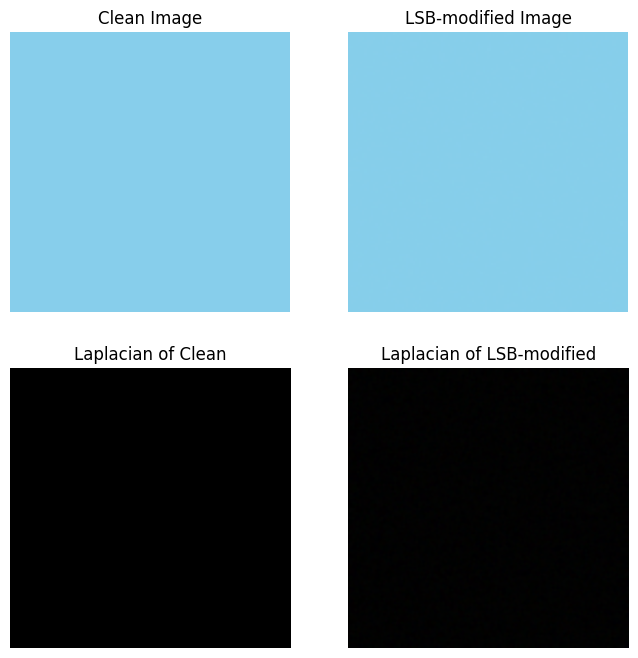

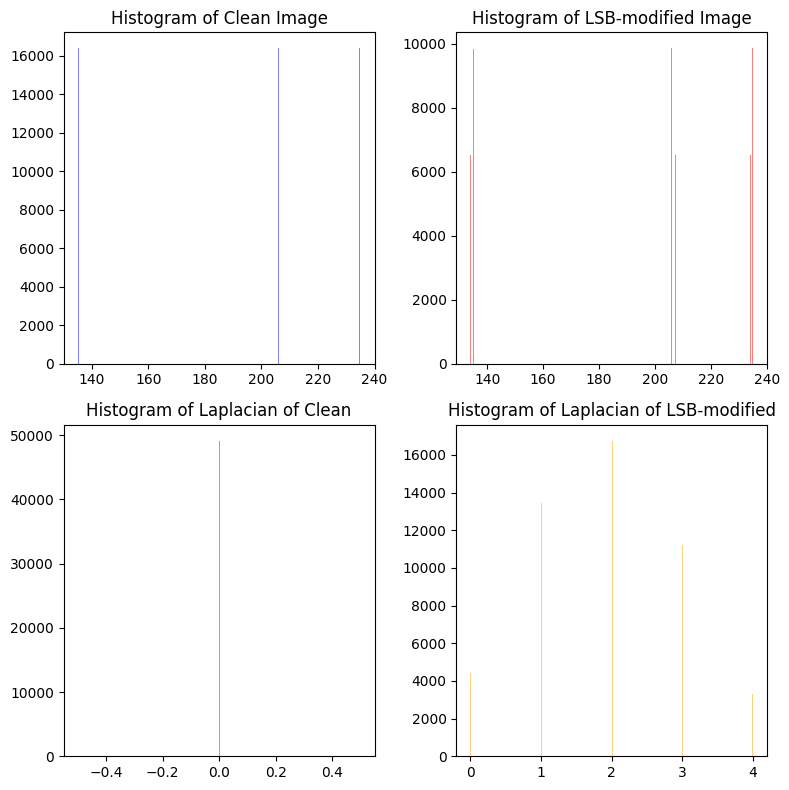

Prédiction : Clean (Probas: Clean=1.000, Stego=0.000)
Prédiction : Stego (Probas: Clean=0.000, Stego=1.000)


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

height, width = 128, 128
clean_img1 = np.ones((height, width, 3), dtype=np.uint8) * [135, 206, 235] 

def apply_lsb_modification(image, prob=0.4):
    modified = image.copy()
    mask = np.random.rand(*image.shape) < prob
    modified[mask] ^= 1
    return modified

stego_img1 = apply_lsb_modification(clean_img1, prob=0.4)

def compute_laplacian(img):
    img = img.astype(np.float32)
    laplacian = np.zeros_like(img, dtype=np.float32)
    for c in range(3):
        lap = cv2.Laplacian(img[:, :, c], cv2.CV_32F)
        laplacian[:, :, c] = cv2.convertScaleAbs(lap)
    return laplacian.astype(np.uint8)

def apply_laplacian_rgb(img_pil, noise="none"):
    img_np = np.array(img_pil, dtype=np.float32)

    if noise == "gaussian":
        img_np = add_gaussian_noise(img_np)
    elif noise == "salt_pepper":
        img_np = add_salt_pepper_noise(img_np)
    elif noise == "blur":
        img_np = add_blur(img_np)

    laplacian_channels = []
    for c in range(3):
        channel = img_np[:, :, c]
        lap = cv2.Laplacian(channel, cv2.CV_32F)
        lap = cv2.convertScaleAbs(lap)
        laplacian_channels.append(lap)

    img_lap = np.stack(laplacian_channels, axis=-1)
    return Image.fromarray(img_lap)


lap_clean = apply_laplacian_rgb(clean_img)#compute_laplacian(clean_img)
lap_stego = apply_laplacian_rgb(stego_img)#compute_laplacian(stego_img)
lap_clean = np.array(lap_clean)
lap_stego = np.array(lap_stego)

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
axs[0, 0].imshow(clean_img)
axs[0, 0].set_title("Clean Image")
axs[0, 1].imshow(stego_img)
axs[0, 1].set_title("LSB-modified Image")
axs[1, 0].imshow(lap_clean)
axs[1, 0].set_title("Laplacian of Clean")
axs[1, 1].imshow(lap_stego)
axs[1, 1].set_title("Laplacian of LSB-modified")

fig, axs2= plt.subplots(2, 2, figsize=(8, 8))
axs2[0, 0].hist(clean_img.ravel(), bins=256, color='blue', alpha=0.5)
axs2[0, 0].set_title("Histogram of Clean Image")
axs2[0, 1].hist(stego_img.ravel(), bins=256, color='red', alpha=0.5)
axs2[0, 1].set_title("Histogram of LSB-modified Image")
axs2[1, 0].hist(lap_clean.ravel(), bins=256, color='green', alpha=0.5)
axs2[1, 0].set_title("Histogram of Laplacian of Clean")
axs2[1, 1].hist(lap_stego.ravel(), bins=256, color='orange', alpha=0.5)
axs2[1, 1].set_title("Histogram of Laplacian of LSB-modified")

for ax in axs.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()


images = [clean_img1, stego_img1]
for image_path in images:
    img_lap = apply_laplacian_rgb(image_path, noise=noise_type)
    input_tensor = transform(img_lap).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.softmax(output, dim=1)
        pred = torch.argmax(prob, dim=1).item()

    print(f"Prédiction : {'Stego' if pred == 1 else 'Clean'} (Probas: Clean={prob[0,0]:.3f}, Stego={prob[0,1]:.3f})")




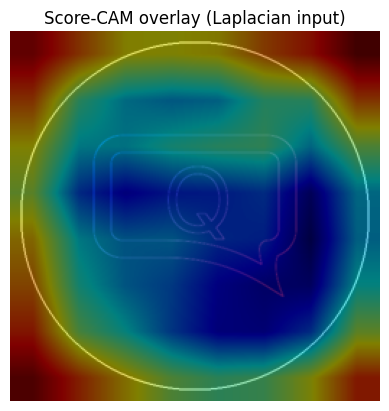

In [42]:
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ---- Laplacian + Preprocessing ----


transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3)
])

# ---- Load model ----
model = models.resnet18(pretrained=True)
model.fc = torch.nn.Sequential(
    torch.nn.Dropout(0.5),
    torch.nn.Linear(model.fc.in_features, 2)  # Adjust for binary classification
)
model.eval()

# ---- Forward Hook for Score-CAM ----
fmap = []
def hook_fn(m, i, o): fmap.append(o)
model.layer4.register_forward_hook(hook_fn)

clean_img = "image_04001_url_0.png"
clean_dir = "../stegoimagesdataset/test/test/stego"
img = Image.open(os.path.join(clean_dir, clean_img)).convert("RGB")
img_lap = apply_laplacian_rgb(img, noise="none")
input_tensor = transform(img_lap).unsqueeze(0)

# ---- Score-CAM ----
with torch.no_grad():
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()
    act_maps = fmap[0][0]  # shape: [C, H, W]
    weights = []
    for i in range(act_maps.shape[0]):
        mask = F.interpolate(act_maps[i][None, None], size=(256, 256), mode='bilinear')
        masked_input = input_tensor * mask
        score = model(masked_input)[0, pred_class]
        weights.append(score.item())
    weights = torch.tensor(weights)
    cam = (act_maps * weights.view(-1,1,1)).sum(0).relu()
    cam = (cam - cam.min()) / (cam.max() - cam.min())

# ---- Overlay ----
# Resize the CAM to input image size
cam_resized = cv2.resize(cam.numpy(), (256, 256))

# Apply colormap on the resized CAM
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)

# Prepare the original image for overlay
img_np = np.array(img_lap.resize((256, 256)))

# Ensure the image is in uint8 format
if img_np.dtype != np.uint8:
    img_np = np.uint8(img_np)

# Overlay
overlay = cv2.addWeighted(img_np, 0.5, heatmap, 0.5, 0)
plt.imshow(overlay)
plt.title("Score-CAM overlay (Laplacian input)")
plt.axis("off")
plt.show()
